In [48]:
import pandas as pd
import sklearn.feature_extraction
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing

%matplotlib inline

import matplotlib.pyplot as plt

plt.style.use("ggplot")
import warnings

warnings.filterwarnings("ignore")

In [49]:
df = pd.read_csv('../data/bank_train.csv')
labels = pd.read_csv('../data/bank_train_target.csv', header=None)

In [50]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,high.school,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,university.degree,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,basic.4y,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,university.degree,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,university.degree,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27595 entries, 0 to 27594
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             27595 non-null  int64  
 1   job             27595 non-null  str    
 2   marital         27595 non-null  str    
 3   education       27595 non-null  str    
 4   default         27595 non-null  str    
 5   housing         27595 non-null  str    
 6   loan            27595 non-null  str    
 7   contact         27595 non-null  str    
 8   month           27595 non-null  str    
 9   day_of_week     27595 non-null  str    
 10  duration        27595 non-null  int64  
 11  campaign        27595 non-null  int64  
 12  pdays           27595 non-null  int64  
 13  previous        27595 non-null  int64  
 14  poutcome        27595 non-null  str    
 15  emp.var.rate    27595 non-null  float64
 16  cons.price.idx  27595 non-null  float64
 17  cons.conf.idx   27595 non-null  float64
 1

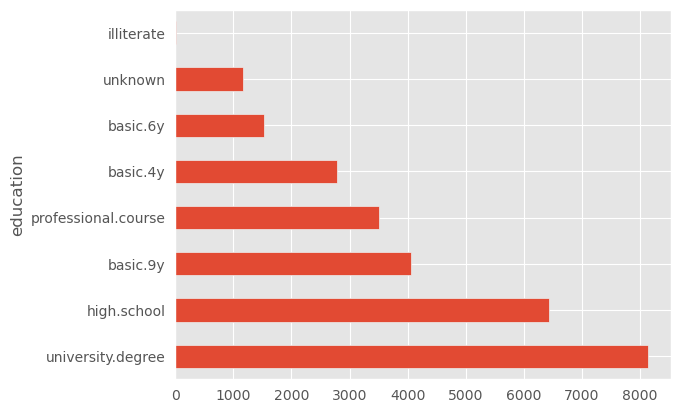

In [52]:
df["education"].value_counts().plot.barh();

In [53]:
label_encoder = sklearn.preprocessing.LabelEncoder()

{0: 'basic.4y', 1: 'basic.6y', 2: 'basic.9y', 3: 'high.school', 4: 'illiterate', 5: 'professional.course', 6: 'university.degree', 7: 'unknown'}


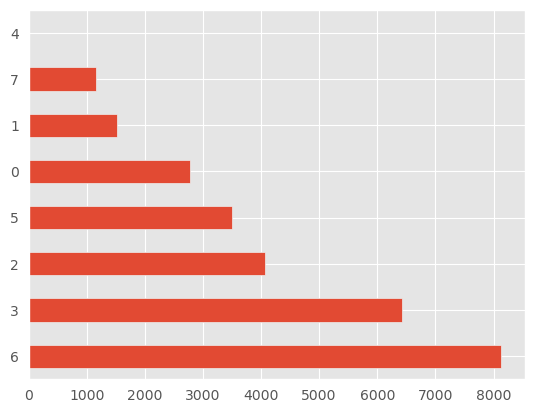

In [54]:
mapped_education = pd.Series(label_encoder.fit_transform(df["education"]))
mapped_education.value_counts().plot.barh()
print(dict(enumerate(label_encoder.classes_)))

In [55]:
df["education"] = mapped_education
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,student,single,3,no,no,no,telephone,jun,mon,901,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1
1,46,admin.,married,6,no,yes,no,cellular,aug,tue,208,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1
2,49,blue-collar,married,0,unknown,yes,yes,telephone,jun,tue,131,5,999,0,nonexistent,1.4,94.465,-41.8,4.864,5228.1
3,31,technician,married,6,no,no,no,cellular,jul,tue,404,1,999,0,nonexistent,-2.9,92.469,-33.6,1.044,5076.2
4,42,housemaid,married,6,no,yes,no,telephone,nov,mon,85,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8


In [56]:
categorical_columns = df.columns[df.dtypes == "str"].union(["education"])
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,26,8,2,3,0,0,0,1,4,1,901,1,999,0,1,1.4,94.465,-41.8,4.961,5228.1
1,46,0,1,6,0,2,0,0,1,3,208,2,999,0,1,1.4,93.444,-36.1,4.963,5228.1
2,49,1,1,0,1,2,2,1,4,3,131,5,999,0,1,1.4,94.465,-41.8,4.864,5228.1
3,31,9,1,6,0,0,0,0,3,3,404,1,999,0,1,-2.9,92.469,-33.6,1.044,5076.2
4,42,3,1,6,0,2,0,1,7,1,85,1,999,0,1,-0.1,93.200,-42.0,4.191,5195.8


In [57]:
df.loc[1].job - df.loc[2].job  # теперь все столбцы имеют цифровые значения

np.float64(-1.0)

In [58]:
def logistic_regression_accuracy_on(dataframe, labels):
    features = dataframe.to_numpy()
    (
        train_features,
        test_features,
        train_labels,
        test_labels,
    ) = sklearn.model_selection.train_test_split(features, labels)

    lr = sklearn.linear_model.LogisticRegression()
    lr.fit(train_features, train_labels)
    return sklearn.metrics.classification_report(test_labels, lr.predict(test_features))


print(logistic_regression_accuracy_on(df[categorical_columns], labels))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6107
           1       0.67      0.00      0.01       792

    accuracy                           0.89      6899
   macro avg       0.78      0.50      0.47      6899
weighted avg       0.86      0.89      0.83      6899



In [59]:
one_hot_example = pd.DataFrame([{i: 0 for i in range(10)}])
one_hot_example.loc[0, 6] = 1
one_hot_example

,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,1,0,0,0


In [60]:
onehot_encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False)

In [61]:
encoded_categorical_columns = pd.DataFrame(onehot_encoder.fit_transform(df[categorical_columns]))
encoded_categorical_columns.head()

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [62]:
print(logistic_regression_accuracy_on(encoded_categorical_columns, labels))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      6112
           1       0.62      0.17      0.26       787

    accuracy                           0.89      6899
   macro avg       0.76      0.58      0.60      6899
weighted avg       0.87      0.89      0.86      6899



# Hashing_trick

In [63]:
for s in ("university.degree", "high.school", "illiterate"):
    print(s, "->", hash(s))

university.degree -> 5791743998557281117
high.school -> -1065701709190164105
illiterate -> 6737856117864917198


In [71]:
hash_space = 25
for s in ("university.degree", "high.school", "illiterate"):
    print(s, "->", hash(s) % hash_space)

university.degree -> 17
high.school -> 20
illiterate -> 23


In [65]:
hashing_example = pd.DataFrame([{i: 0.0 for i in range(hash_space)}])
for s in ("job=student", "marital=single", "day_of_week=mon"):
    print(s, "->", hash(s) % hash_space)
    hashing_example.loc[0, hash(s) % hash_space] = 1

hashing_example

job=student -> 14
marital=single -> 8
day_of_week=mon -> 1


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
